<a href="https://colab.research.google.com/github/Kaitokidbua/ASEAN_Transport/blob/main/ASEAN_Part8_UrbanScale_Fig.27-32.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ตั้งค่าสไตล์ของกราฟ
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif' # รองรับภาษาอังกฤษและอ่านง่าย

# --- 1. คลีนและเตรียมข้อมูล ---
df = pd.read_csv("ASEAN_Urban_Growth_Final_with_Mode.csv")

# แปลงวันที่
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')

# คลีนข้อมูล: ตัดช่วงที่ Ridership เป็น 0 ออก (ถือว่ายังไม่เปิดบริการ)
# เพื่อไม่ให้ตัวหาร (จำนวนวัน) เยอะเกินความจริงจนค่าเฉลี่ยต่ำ
df_active = df[df['Ridership'] > 0].copy()

# คำนวณ Per Capita รายวัน (เพื่อให้สัมพันธ์กับ Population ของปีนั้นๆ)
df_active['Daily_Per_Capita'] = df_active['Ridership'] / (df_active['Population_Million'] * 1_000_000)

# สรุปข้อมูลรายเมือง (ใช้วิธีหาค่าเฉลี่ยรายวันเพื่อแก้ปัญหาจำนวนปีที่มาไม่เท่ากัน)
city_analysis = df_active.groupby(['City', 'Country']).agg({
    'Population_Million': 'last',          # ใช้จำนวนประชากรล่าสุดที่มีใน Dataset
    'Ridership': 'mean',                  # จำนวนผู้โดยสารเฉลี่ยต่อวัน (Daily Avg Volume)
    'Daily_Per_Capita': 'mean'            # utilization เฉลี่ยต่อวัน (Daily Utilization)
}).reset_index()

# เปลี่ยนชื่อ Column ให้สื่อความหมายชัดเจน
city_analysis.columns = ['City', 'Country', 'Latest_Pop_M', 'Avg_Daily_Ridership', 'Utilization_Index']

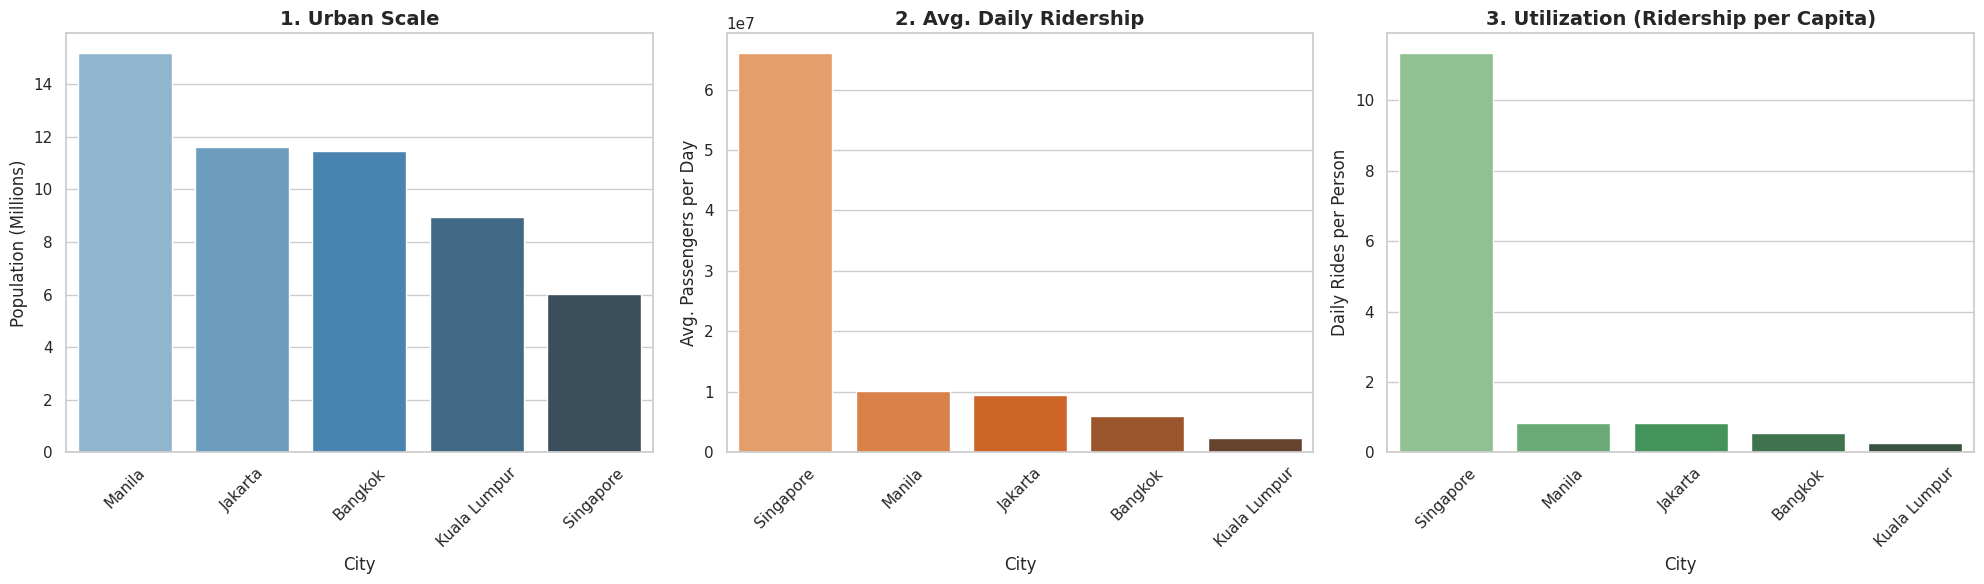

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# กราฟ Population
sns.barplot(data=city_analysis.sort_values('Latest_Pop_M', ascending=False),
            x='City', y='Latest_Pop_M', ax=axes[0], hue = 'City', palette='Blues_d')
axes[0].set_title('1. Urban Scale', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Population (Millions)')

# กราฟ Ridership (คนใช้ต่อวัน)
sns.barplot(data=city_analysis.sort_values('Avg_Daily_Ridership', ascending=False),
            x='City', y='Avg_Daily_Ridership', ax=axes[1], hue = 'City', palette='Oranges_d')
axes[1].set_title('2. Avg. Daily Ridership', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Avg. Passengers per Day')

# กราฟ Efficiency (คนใช้ต่อหัวต่อวัน)
sns.barplot(data=city_analysis.sort_values('Utilization_Index', ascending=False),
            x='City', y='Utilization_Index', ax=axes[2], hue = 'City', palette='Greens_d')
axes[2].set_title('3. Utilization (Ridership per Capita)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Daily Rides per Person')

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

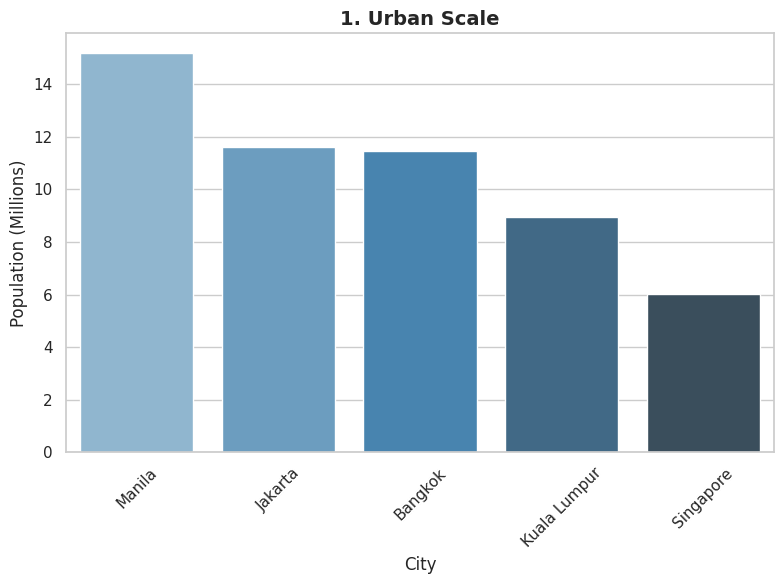

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(data=city_analysis.sort_values('Latest_Pop_M', ascending=False),
            x='City', y='Latest_Pop_M', hue='City', palette='Blues_d', legend=False)

plt.title('1. Urban Scale', fontsize=14, fontweight='bold')
plt.ylabel('Population (Millions)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

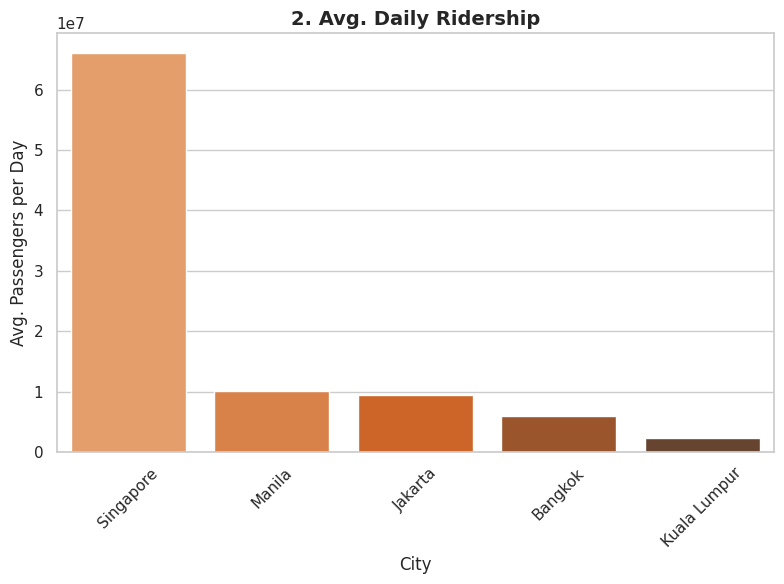

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(data=city_analysis.sort_values('Avg_Daily_Ridership', ascending=False),
            x='City', y='Avg_Daily_Ridership', hue='City', palette='Oranges_d', legend=False)

plt.title('2. Avg. Daily Ridership', fontsize=14, fontweight='bold')
plt.ylabel('Avg. Passengers per Day')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

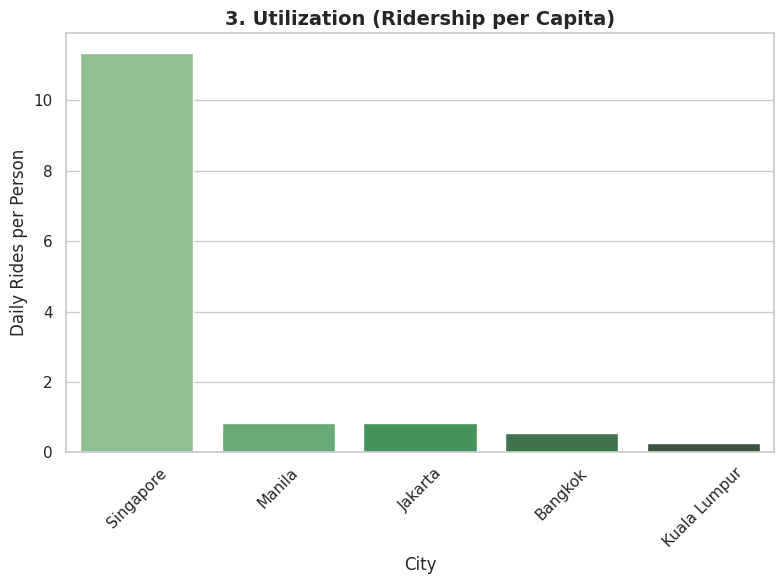

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(data=city_analysis.sort_values('Utilization_Index', ascending=False),
            x='City', y='Utilization_Index', hue='City', palette='Greens_d', legend=False)

plt.title('3. Utilization (Ridership per Capita)', fontsize=14, fontweight='bold')
plt.ylabel('Daily Rides per Person')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

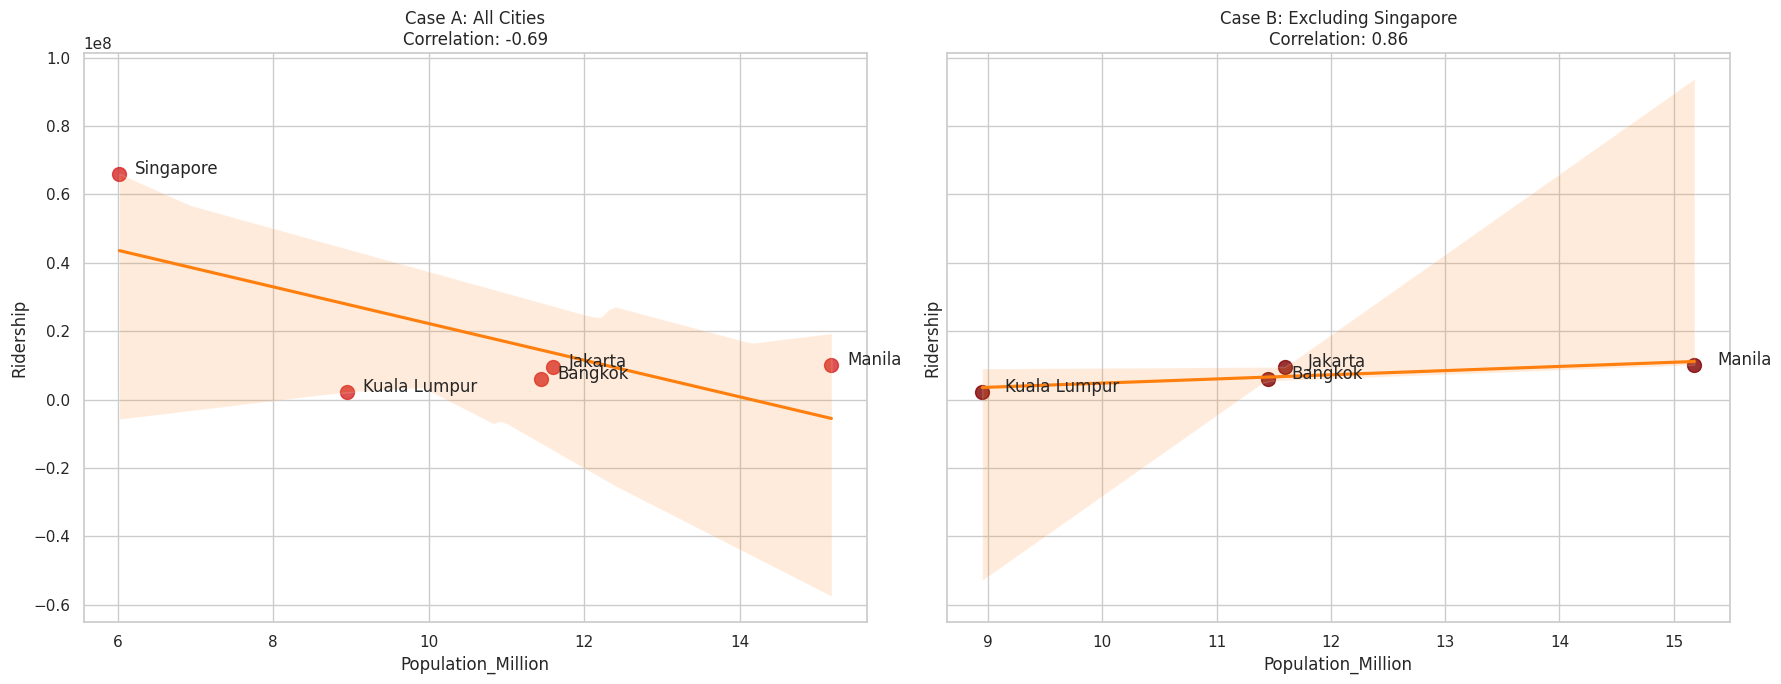

In [ ]:
# --- 1. เตรียมข้อมูล (ใช้ Logic เดิมที่คลีนแล้ว) ---
df = pd.read_csv("ASEAN_Urban_Growth_Final_with_Mode.csv")
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')
df_active = df[df['Ridership'] > 0].copy()

df_active['Daily_Per_Capita'] = df_active['Ridership'] / (df_active['Population_Million'] * 1_000_000)

city_analysis = df_active.groupby(['City', 'Country']).agg({
    'Population_Million': 'last',
    'Ridership': 'mean',
    'Daily_Per_Capita': 'mean',
    'GDP_Billion_USD': 'last' # เพิ่ม GDP เข้ามาวิเคราะห์
}).reset_index()

# --- 2. สร้าง Subsets: รวม SG vs ตัด SG ---
all_cities = city_analysis.copy()
exclude_sg = city_analysis[city_analysis['Country'] != 'Singapore'].copy()

# --- 3. Visualization: Comparative Correlation ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# กราฟแรก: รวมทุกเมือง (สีแดงตามที่ชอบ)
sns.regplot(data=all_cities, x='Population_Million', y='Ridership', ax=ax1,
            scatter_kws={'s':100, 'color':'#d62728'}, line_kws={'color':'#ff7f0e'})
ax1.set_title(f"Case A: All Cities\nCorrelation: {all_cities['Population_Million'].corr(all_cities['Ridership']):.2f}")

# กราฟสอง: ตัดสิงคโปร์ออก (ใช้สีแดงเหมือนเดิมแต่เปลี่ยนโทน)
sns.regplot(data=exclude_sg, x='Population_Million', y='Ridership', ax=ax2,
            scatter_kws={'s':100, 'color':'#800000'}, line_kws={'color':'#ff7f0e'})
ax2.set_title(f"Case B: Excluding Singapore\nCorrelation: {exclude_sg['Population_Million'].corr(exclude_sg['Ridership']):.2f}")

# ใส่ชื่อเมืองกำกับ
for df_sub, ax in zip([all_cities, exclude_sg], [ax1, ax2]):
    for i, txt in enumerate(df_sub['City']):
        ax.annotate(txt, (df_sub['Population_Million'].iloc[i]+0.2, df_sub['Ridership'].iloc[i]))

plt.tight_layout()
plt.show()

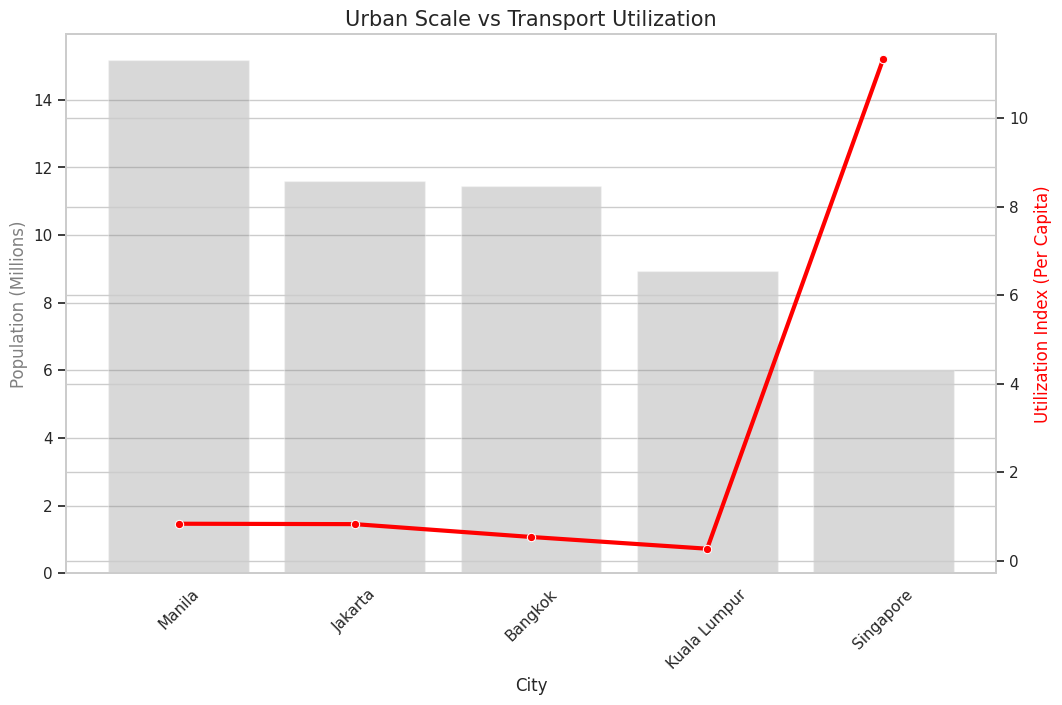

In [ ]:
# ส่วนที่ 2: Dual Axis Chart (Scale vs Efficiency)
fig, ax1 = plt.subplots(figsize=(12, 7))

# แกน 1: ขนาดประชากร (Bar)
sns.barplot(data=city_analysis.sort_values('Latest_Pop_M', ascending=False),
            x='City', y='Latest_Pop_M', alpha=0.3, color='gray', ax=ax1)
ax1.set_ylabel('Population (Millions)', color='gray', fontsize=12)

# แกน 2: ประสิทธิภาพ (Line)
ax2 = ax1.twinx()
sns.lineplot(data=city_analysis.sort_values('Latest_Pop_M', ascending=False),
             x='City', y='Utilization_Index', marker='o', color='red', linewidth=3, ax=ax2)
ax2.set_ylabel('Utilization Index (Per Capita)', color='red', fontsize=12)

plt.title('Urban Scale vs Transport Utilization', fontsize=15)
ax1.tick_params(axis='x', rotation=45)
plt.show()